In [1]:
from torch.distributions import Poisson, Normal, MultivariateNormal
from gpzoo.gp import SVGP, MGGP_SVGP, VNNGP, MGGP_WSVGP, MGGP_VNNGP
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF, batched_MGGP_Matern32
from gpzoo.utilities import build_sparse_from_Kzx_knnidx, symmetrize_by_copy, add_jitter, init_Lu
import torch
import matplotlib.pyplot as plt

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
torch.manual_seed(0)

In [3]:
N = 50

In [4]:
X1 = torch.linspace(-2, 2, N)[:, None]
groupsX1 = torch.zeros_like(X1.squeeze()).type(torch.long)
X2 = X1
groupsX2 = torch.ones_like(X2.squeeze()).type(torch.long)
X = torch.cat((X1, X2))
groupsX = torch.cat((groupsX1, groupsX2)).squeeze().type(torch.long)

In [12]:
K= 20
n_groups = 2


group_diff_params = [1e-1, 1.0, 1e1, 1e2]

Ws = []

for group_diff_param in group_diff_params:

    M = 2*N
    
    Z = X
    groupsZ = groupsX
    
    kernel = batched_MGGP_Matern32(sigma=1.0, lengthscale=0.4, group_diff_param=group_diff_param, n_groups=2)
    
    
    W = init_Lu(kernel, X, groupsX, Z, groupsZ, K)
    
    gp = MGGP_VNNGP(kernel, dim=1, M=M, n_groups=n_groups, jitter=1e-5, K=K)
    
    gp.Z = torch.nn.Parameter(X)
    gp.groupsZ = torch.nn.Parameter( groupsX, requires_grad=False)
    gp.mu = torch.nn.Parameter(torch.zeros(2*N))
    
    knn_idx = gp.calculate_knn(X)
    gp.knn_idx = knn_idx[:, :-1]
    gp.knn_idz= knn_idx[:, 1:]
    
    
    gp.Lu = torch.nn.Parameter(W)
    Ws.append(W)

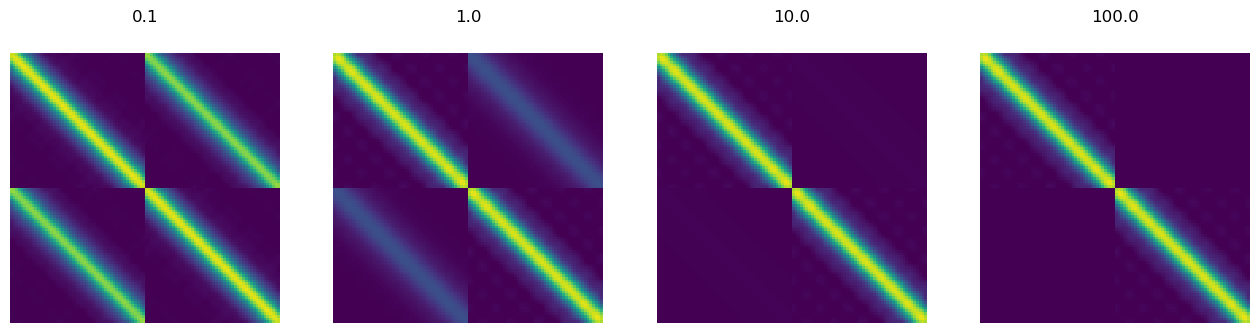

In [13]:
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    ax.matshow((Ws[i]@Ws[i].T).detach(), vmin=0, vmax=1.0)
    ax.set_axis_off()
    ax.set_title(group_diff_params[i])


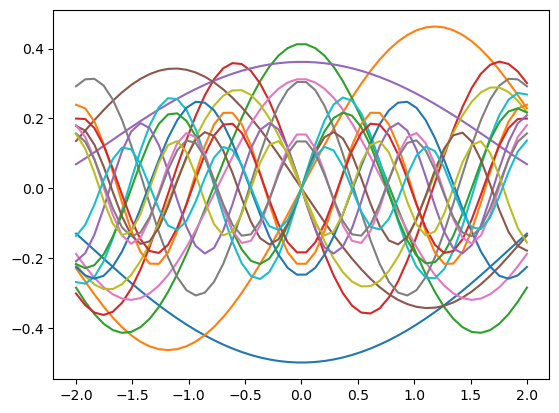

In [14]:
for i in range(K):
    plt.plot(X1, Ws[1][:N, i].detach());

In [8]:
T = 120

all_samples = []


for i in range(4):
    samples = []
    for t in range(0, T):
        pi_range = torch.linspace(-1, 1, K)*torch.pi
        value = pi_range+ (t*2*torch.pi/T)
        
        sample = (Ws[i][:, :K]@torch.sin(2*value)).detach()
        samples.append(sample)
        
    all_samples.append(samples)

# sample = (W@torch.randn(K)).detach()


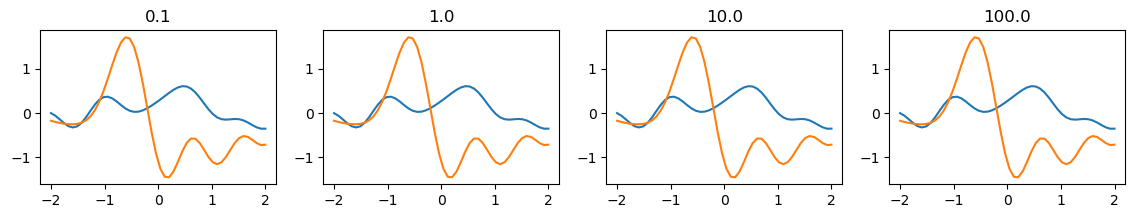

In [9]:
fig = plt.figure(figsize=(14, 2))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    # ax.matshow((Ws[i]@Ws[i].T).detach())
    ax.plot(X1, sample[:N])
    ax.plot(X2, sample[N:])
    # ax.set_axis_off()
    ax.set_title(group_diff_params[i])




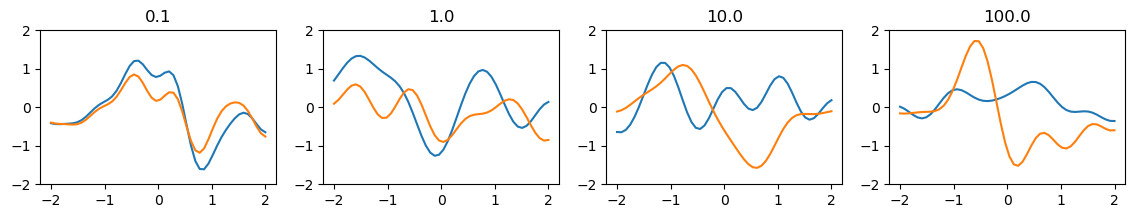

In [10]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from tqdm import tqdm

fig, ax = plt.subplots(1, 4, figsize=(14,2))

def update(iteration):
    
        

    for i in range(4):
        ax[i].cla()
        curr_sample = all_samples[i][iteration]
        ax[i].plot(X1, curr_sample[:N])
        ax[i].plot(X2, curr_sample[N:])
        ax[i].set_ylim([-2, 2])
        ax[i].set_title(group_diff_params[i])

#     fig.suptitle(f"Iteration: {iteration}, Loss: {losses[iteration*10]:0.2f}")
#     fig.tight_layout()

anim = FuncAnimation(fig, update, frames=np.arange(0, 120, 1), interval=100)
# anim.save('pnmf.mp4',
#          writer=animation.FFMpegWriter(fps=50, bitrate=2000, codec='h264'),
#          dpi=50)
anim.save('mggp_test_multiple_matern32.gif', fps=20, dpi=100)

In [11]:
K= 20
n_groups = 2


group_diff_params = [1e-1, 1.0, 1e1, 1e2]

Ws = []

for group_diff_param in group_diff_params:

    M = 2*N
    
    Z = X
    groupsZ = groupsX
    
    kernel = batched_MGGP_RBF(sigma=1.0, lengthscale=0.4, group_diff_param=group_diff_param, n_groups=2)
    
    
    
    
    gp = MGGP_VNNGP(kernel, dim=1, M=M, n_groups=n_groups, jitter=1e-5, K=K)
    
    gp.Z = torch.nn.Parameter(X)
    gp.groupsZ = torch.nn.Parameter( groupsX, requires_grad=False)
    gp.mu = torch.nn.Parameter(torch.zeros(2*N))
    
    knn_idx = gp.calculate_knn(X)
    gp.knn_idx = knn_idx[:, :-1]
    gp.knn_idz= knn_idx[:, 1:]

    Kxx, Kzx, Kzz = gp.forward_kernels(X, groupsX)
    A = build_sparse_from_Kzx_knnidx(Kzx, knn_idx[:,:-1], 2*N)
    A = symmetrize_by_copy(A)
    U, S, V = torch.svd_lowrank(A, q=K, niter=1000)
    W = U*(S**0.5).detach()
    
    
    gp.Lu = torch.nn.Parameter(W)
    Ws.append(W)

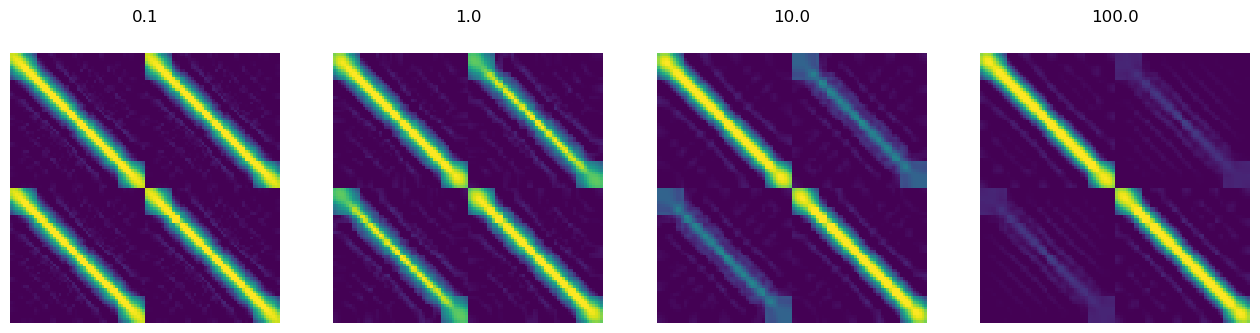

In [12]:
fig = plt.figure(figsize=(16, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    ax.matshow((Ws[i]@Ws[i].T).detach(), vmin=0, vmax=1.0)
    ax.set_axis_off()
    ax.set_title(group_diff_params[i])


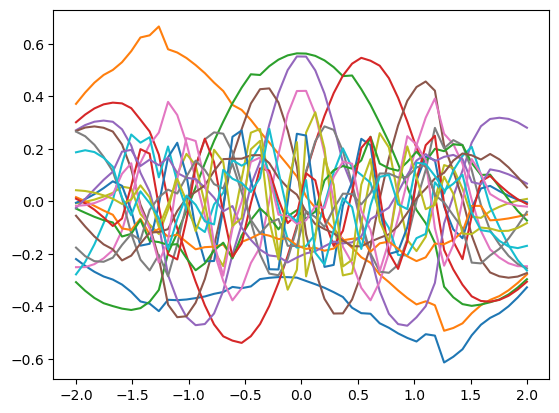

In [13]:
for i in range(K):
    plt.plot(X1, Ws[1][:N, i].detach());

In [14]:
T = 120

all_samples = []


for i in range(4):
    samples = []
    for t in range(0, T):
        pi_range = torch.linspace(-1, 1, K)*torch.pi
        value = pi_range+ (t*2*torch.pi/T)
        
        sample = (Ws[i][:, :K]@torch.sin(2*value)).detach()
        samples.append(sample)
        
    all_samples.append(samples)

# sample = (W@torch.randn(K)).detach()


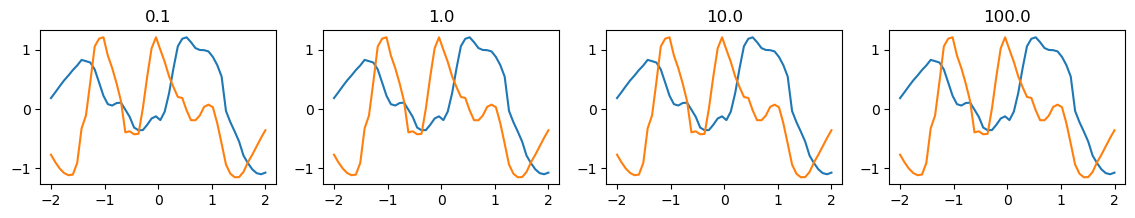

In [15]:
fig = plt.figure(figsize=(14, 2))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    # ax.matshow((Ws[i]@Ws[i].T).detach())
    ax.plot(X1, sample[:N])
    ax.plot(X2, sample[N:])
    # ax.set_axis_off()
    ax.set_title(group_diff_params[i])




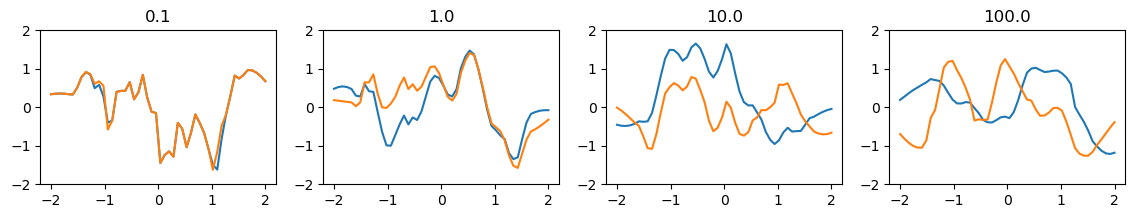

In [16]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from tqdm import tqdm

fig, ax = plt.subplots(1, 4, figsize=(14,2))

def update(iteration):
    
        

    for i in range(4):
        ax[i].cla()
        curr_sample = all_samples[i][iteration]
        ax[i].plot(X1, curr_sample[:N])
        ax[i].plot(X2, curr_sample[N:])
        ax[i].set_ylim([-2, 2])
        ax[i].set_title(group_diff_params[i])

#     fig.suptitle(f"Iteration: {iteration}, Loss: {losses[iteration*10]:0.2f}")
#     fig.tight_layout()

anim = FuncAnimation(fig, update, frames=np.arange(0, 120, 1), interval=100)
# anim.save('pnmf.mp4',
#          writer=animation.FFMpegWriter(fps=50, bitrate=2000, codec='h264'),
#          dpi=50)
anim.save('mggp_knn_test_multiple.gif', fps=20, dpi=100)